<div style="display: flex; align-items: center;">
    <div style="display: flex; flex-direction: column; align-items: center;">
        <h1 style="text-align: right;">Centro de Investigación en Matemáticas, A.C.</h1>
        <h2 style="text-align: right;">Modelos Generativos Profundos</h2>
        <h2 style="text-align: right;">Jose Miguel Saavedra Aguilar</h2>
        <h3 style="text-align: right;">Tarea 3</h3>
    </div>
    <img src="https://www.cimat.mx/~adolfofest/images/LOGOTIPO_SIN_FONDO-02.png" alt="CIMAT Logo" width="200" style="float: left;">
</div>


---

## Problema 1
Suponemos que $n$ es la dimension de los datos. Explicar por qué el método de Sliced Score Matching propuesto en el artículo necesita 1 solo paso de backpropagation en lugar de $n$ como el algoritmo original de score matching.

### Respuesta
La pregunta es un poco engañosa, pues es posible tener el caso en que SSM utilice un solo paso de backpropagation, pero el número exacto sería $M$ siguiendo la notación del artículo. $M$ es el número de vectores que utilizamos por paso en SSM. Y si bien, dice que en el caso $M=1$ obtiene resultados decentes, en la sección de resultados habla de $M=32$ e incluso de $M=100$, por lo que el número en realidad sería $M$ pasos de backpropagation.
En el caso usual, requerimos hacer un paso por cada elemento de la diagonal de la Hessiana para poder calcular su traza, por lo que el número de pasos de backpropagation es $n$.

## Problema 2
Implementa el método de sliced score matching en PyTorch para generar imágenes a partir de los datos de MNIST.

Implementamos el método de Latent Sliced Score Matching, una variante en la que utilizamos Sliced Score Matching en el espacio latente de un variational autoencoder para evitar las suposiciones del encoder y del espacio latente, por ejemplo, normalidad. Esto fue resultado de que el método de Sliced Score Matching en el espacio de pixeles no generaba correctamente los dígitos, incluso cuando logré que el resultado no fuera ruido puro, se generaban imágenes negras con algunos círuclos blancos, no dígitos. Este método me parece una forma mucho más tractable de implementar SSM, pues en el espacio de pixeles el método es muy sensible a parámetros, tasa de aprendizaje, etc. además que tarda casi un día de entrenamiento para conseguir resultados que no sean totalmente ruido.

Estos métodos fueron propuestos por Arash Vahdat, Karsten Kreis, Jan Kautz y se pueden consultar en https://arxiv.org/abs/2106.05931?spm=a2ty_o01.29997173.0.0.6792c921605cct&file=2106.05931

In [ ]:
!pip install torchinfo

In [ ]:
# Core imports for PyTorch, datasets, and plotting.
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import os
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
# Optional helper to print model summaries (not required for training).
from torchinfo import summary


In [ ]:
# Device selection: choose GPU if available, else CPU.
# Also detects common TPU environment variables used in hosted notebooks.
# This makes subsequent `.to(device)` calls portable.
if torch.cuda.is_available():
    device = torch.device("cuda")
elif 'TPU_ACCELERATOR_TYPE' in os.environ or 'COLAB_TPU_1vm' in os.environ:
    # Minimal TPU support if running in an environment that exposes XLA.
    import torch_xla
    import torch_xla.core.xla_model as xm
    device = xm.xla_device()
else:
    device = torch.device("cpu")
print(f"Using device: {device}")


Using device: cuda


Dicho lo anterior, utilizaremos la VAE de la tarea 2 que sabemos generaba los dígitos de MNIST decentemente, sin embargo aún eran un poco borrosos. Únicamente la modificamos a ser condicionada por el valor real del dígito para mejores resultados. Esto lo hacemos a través de un embedding.

In [ ]:
# ----------------------------
# Data loaders: one for VAE training ([0,1] range),
# and one (optional) for SSM-related augmentations in [-1,1].
# VAE uses sigmoid outputs so inputs are scaled to [0,1].
transform_vae = transforms.Compose([
    transforms.ToTensor(),  # outputs tensor in [0,1]
])

train_dataset_vae = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform_vae
)
train_loader_vae = DataLoader(train_dataset_vae, batch_size=128, shuffle=True, num_workers=2)

# Augmented loader scaled to [-1,1] (used for SSM in pixel space experiments).
# Padding and small rotations are applied as minimal augmentation.
transform_ssm = transforms.Compose([
    transforms.Pad(2),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    lambda x: x * 2 - 1  # map [0,1] -> [-1,1]
])
train_dataset_ssm = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform_ssm
)
train_loader_ssm = DataLoader(train_dataset_ssm, batch_size=128, shuffle=True, num_workers=2)


In [ ]:
# ----------------------------
# VAE helper: reparameterization trick
# Converts (mu, log_var) -> sample z = mu + sigma * eps, where eps~N(0,I).
def reparameterize(mu, log_var):
    # log_var is log(sigma^2); compute sigma and sample noise of same shape.
    std = torch.exp(0.5 * log_var)
    eps = torch.randn_like(std)
    return mu + eps * std


In [ ]:
# Conditional encoder: takes flattened image x and label y, returns (mu, log_var).
# We use an embedding to condition on the digit class and concatenate it to the input.
class ConditionalEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, z_dim, num_classes=10):
        super().__init__()
        # Embedding provides a learned per-class vector to condition the encoder.
        self.embed = nn.Embedding(num_classes, hidden_dim)
        # FC expects flattened image concatenated with class embedding.
        self.fc1 = nn.Linear(input_dim + hidden_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, z_dim)
        self.fc_logvar = nn.Linear(hidden_dim, z_dim)

    def forward(self, x, y):
        # x: [B, input_dim], y: [B] (labels)
        class_emb = self.embed(y)  # [B, hidden_dim]
        h = torch.cat([x, class_emb], dim=1)
        h = F.relu(self.fc1(h))
        mu = self.fc_mu(h)
        log_var = self.fc_logvar(h)
        return mu, log_var


In [ ]:
# Conditional decoder: maps latent z and label y back to image space.
# Outputs are squashed with sigmoid to match [0,1] image range used for VAE.
class ConditionalDecoder(nn.Module):
    def __init__(self, z_dim, hidden_dim, output_dim, num_classes=10):
        super().__init__()
        self.embed = nn.Embedding(num_classes, hidden_dim)
        self.fc1 = nn.Linear(z_dim + hidden_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, z, y):
        class_emb = self.embed(y)
        h = torch.cat([z, class_emb], dim=1)
        h = F.relu(self.fc1(h))
        # Sigmoid to give pixel intensities in [0,1] for the VAE reconstruction loss.
        return torch.sigmoid(self.fc_out(h))


In [ ]:
# Simple conditional VAE wrapper combining encoder and decoder.
class ConditionalVAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, z_dim, num_classes=10):
        super().__init__()
        self.encoder = ConditionalEncoder(input_dim, hidden_dim, z_dim, num_classes)
        self.decoder = ConditionalDecoder(z_dim, hidden_dim, input_dim, num_classes)

    def forward(self, x, y):
        # Returns reconstructed x and the encoder's (mu, log_var).
        mu, log_var = self.encoder(x, y)
        z = reparameterize(mu, log_var)
        x_recon = self.decoder(z, y)
        return x_recon, mu, log_var


Primero, debemos entrenar el VAE utilizando el ELBO como en un VAE usual, por lo que así lo haremos.

In [ ]:
# ----------------------------
# VAE loss (ELBO): reconstruction + KL divergence.
# We treat the reconstruction term as an MSE (Gaussian NLL with fixed variance).
def vae_loss(x, x_recon, mu, log_var):
    # Reconstruction loss summed over all elements (matches typical ELBO formulation).
    recon_loss = F.mse_loss(x_recon, x, reduction="sum")
    # KL divergence between q(z|x) ~ N(mu, sigma^2) and p(z) ~ N(0,I).
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return recon_loss + kl_loss


Ahora, creamos la red de score, en este caso podemos utilizar una MLP, mientras que cuando trabajamos en el espacio de pixeles estabamos utilizando una U-NET como lo dijimos en clase.

In [ ]:
# Score network in latent space conditioned on class y.
# Given latent z, the network outputs an estimate of the score (gradient of log-density w.r.t z).
class ConditionalLatentScoreNet(nn.Module):
    def __init__(self, z_dim, hidden_dim=256, num_classes=10):
        super().__init__()
        # Embedding to condition on digit class; concatenated to latent vector.
        self.embed = nn.Embedding(num_classes, hidden_dim)
        self.net = nn.Sequential(
            nn.Linear(z_dim + hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, z_dim)  # output dimension matches latent dim
        )

    def forward(self, z, y):
        class_emb = self.embed(y)
        h = torch.cat([z, class_emb], dim=1)
        return self.net(h)


La pérdida es la misma que tendríamos en un modelo de SSM en el espacio de pixeles, pero aplicado a la variable latente z.

In [ ]:
# ----------------------------
# Latent-space Sliced Score Matching (SSM-VR) loss.
# This implements the Hutchinson / Sliced estimator of trace(Hessian) needed for score matching.
# The loss approximates: E_v[v^T \nabla_z (v^T s(z))] + 0.5 ||s(z)||^2, averaged over random projections v.
def conditional_ssm_vr_loss_latent(score_net, z, y, n_projections=2):
    """
    SSM-VR in latent space (z is [B, D])
    - score_net: network returning score estimates for z conditioned on y.
    - n_projections: number of random Rademacher vectors v to average over.
    """
    B, D = z.shape
    # enable gradients w.r.t z because we compute directional derivatives (Hessian-vector products).
    z = z.requires_grad_(True)
    # network estimate of the score (d log p / dz) for each sample
    s = score_net(z, y)  # shape [B, D]
    v_hessian_v_total = 0.0
    norm_s_sq_total = 0.0
    for _ in range(n_projections):
        # Rademacher random projection in {+1,-1}^D per batch element.
        v = torch.randint(0, 2, (B, D), device=z.device, dtype=torch.float32) * 2 - 1
        # compute v^T s for each batch element (shape [B])
        v_dot_s = (v * s).sum(dim=1)
        # gradient of v_dot_s w.r.t z gives (Jacobian s)^T v = directional derivative;
        # taking dot with v again approximates v^T Hessian v via autodiff.
        grad_vdot_s = torch.autograd.grad(v_dot_s.sum(), z, create_graph=True)[0]
        # v^T (Hessian) v approximated per sample:
        v_hessian_v = (v * grad_vdot_s).sum(dim=1)
        v_hessian_v_total += v_hessian_v
        # squared-norm of score term used in SSM loss
        norm_s_sq = (s ** 2).sum(dim=1)
        norm_s_sq_total += norm_s_sq

    # average over projections to reduce variance
    v_hessian_v_avg = v_hessian_v_total / n_projections
    norm_s_sq_avg = norm_s_sq_total / n_projections
    # final loss averaged over batch
    return (v_hessian_v_avg + 0.5 * norm_s_sq_avg).mean()


In [ ]:
# ----------------------------
# Hyperparameters and model sizes (tune as needed).
input_dim = 28 * 28
hidden_dim = 512
z_dim = 32  # latent dimension (lower dims make SSM cheaper but may reduce fidelity)
epochs_vae = 100
epochs_ssm = 30
lr_vae = 1e-3
lr_ssm = 1e-3


In [ ]:
# ----------------------------
# Stage 1: Train the conditional VAE (reconstruction + KL).
# We train the VAE so that the latent space is a good representation for SSM.
print("=== Stage 1: Training Conditional VAE ===")
vae = ConditionalVAE(input_dim, hidden_dim, z_dim, num_classes=10).to(device)
vae_optimizer = torch.optim.Adam(vae.parameters(), lr=lr_vae)

vae.train()


=== Stage 1: Training Conditional VAE ===


ConditionalVAE(
  (encoder): ConditionalEncoder(
    (embed): Embedding(10, 512)
    (fc1): Linear(in_features=1296, out_features=512, bias=True)
    (fc_mu): Linear(in_features=512, out_features=32, bias=True)
    (fc_logvar): Linear(in_features=512, out_features=32, bias=True)
  )
  (decoder): ConditionalDecoder(
    (embed): Embedding(10, 512)
    (fc1): Linear(in_features=544, out_features=512, bias=True)
    (fc_out): Linear(in_features=512, out_features=784, bias=True)
  )
)

In [ ]:
# Standard training loop for the VAE. Note: x is flattened before passing.
for epoch in range(epochs_vae):
    total_loss = 0.0
    for batch_idx, (x, y) in enumerate(train_loader_vae):
        # Flatten images to vectors and move to device
        x = x.view(x.size(0), -1).to(device)
        y = y.to(device)  # move labels to device

        vae_optimizer.zero_grad()
        x_recon, mu, log_var = vae(x, y)  # pass y to VAE!
        loss = vae_loss(x, x_recon, mu, log_var)
        loss.backward()
        vae_optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader_vae.dataset)
    print(f"VAE Epoch {epoch+1}/{epochs_vae} | Avg ELBO per sample: {avg_loss:.4f}")


VAE Epoch 1/100 | Avg ELBO per sample: 42.5661
VAE Epoch 2/100 | Avg ELBO per sample: 36.5607
VAE Epoch 3/100 | Avg ELBO per sample: 34.3304
VAE Epoch 4/100 | Avg ELBO per sample: 32.1706
VAE Epoch 5/100 | Avg ELBO per sample: 30.9998
VAE Epoch 6/100 | Avg ELBO per sample: 30.0466
VAE Epoch 7/100 | Avg ELBO per sample: 29.2962
VAE Epoch 8/100 | Avg ELBO per sample: 28.6727
VAE Epoch 9/100 | Avg ELBO per sample: 28.2886
VAE Epoch 10/100 | Avg ELBO per sample: 27.9980
VAE Epoch 11/100 | Avg ELBO per sample: 27.8042
VAE Epoch 12/100 | Avg ELBO per sample: 27.6130
VAE Epoch 13/100 | Avg ELBO per sample: 27.4927
VAE Epoch 14/100 | Avg ELBO per sample: 27.3862
VAE Epoch 15/100 | Avg ELBO per sample: 27.3128
VAE Epoch 16/100 | Avg ELBO per sample: 27.2057
VAE Epoch 17/100 | Avg ELBO per sample: 27.1402
VAE Epoch 18/100 | Avg ELBO per sample: 27.0624
VAE Epoch 19/100 | Avg ELBO per sample: 26.9838
VAE Epoch 20/100 | Avg ELBO per sample: 26.9187
VAE Epoch 21/100 | Avg ELBO per sample: 26.8703
V

In [ ]:
# Save the trained VAE weights for reuse later (decoder used by SSM sampler).
torch.save(vae.state_dict(), "vae_mnist.pth")
print("VAE trained and saved.")


VAE trained and saved.


In [ ]:
# ----------------------------
# Stage 2: Train the conditional score network in latent space (SSM).
# We freeze the VAE and sample latents z ~ q(z|x,y) to train the score network.
print("\n=== Stage 2: Training Conditional Latent Score Model ===")
# Freeze VAE parameters so gradients do not flow into encoder/decoder during SSM training.
for param in vae.parameters():
    param.requires_grad_(False)
vae.eval()

# Initialize conditional score network and optimizer
score_net = ConditionalLatentScoreNet(z_dim, num_classes=10).to(device)  # Updated!
score_optimizer = torch.optim.Adam(score_net.parameters(), lr=lr_ssm)
scheduler_ssm = torch.optim.lr_scheduler.ReduceLROnPlateau(score_optimizer, mode='min', factor=0.5, patience=2)

# We'll compute latents on-the-fly from the encoder to avoid storing the whole dataset's latents.
score_net.train()



=== Stage 2: Training Conditional Latent Score Model ===


ConditionalLatentScoreNet(
  (embed): Embedding(10, 256)
  (net): Sequential(
    (0): Linear(in_features=288, out_features=256, bias=True)
    (1): SiLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): SiLU()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): SiLU()
    (6): Linear(in_features=256, out_features=32, bias=True)
  )
)

In [ ]:
# Training loop for latent score network. For each batch we:
# 1) obtain latent samples z ~ q(z|x,y) from the frozen encoder,
# 2) compute the SSM loss on z conditioned on y, and
# 3) update the score network parameters.
for epoch in range(epochs_ssm):
    total_loss = 0.0
    num_batches = 0
    for x, y in train_loader_vae:  # Now using (x, y) instead of just x
        x = x.view(x.size(0), -1).to(device)
        y = y.to(device)  # Move labels to device

        # Use the frozen encoder to sample latents without tracking gradients for the VAE.
        with torch.no_grad():
            mu, log_var = vae.encoder(x, y)  # Pass y to conditional encoder
            z = reparameterize(mu, log_var)  # samples from q(z|x, y)
        # Detach from VAE graph but enable grad for z (we need to compute directional derivatives).
        z = z.detach().requires_grad_(True)  # stop grad from VAE, enable for SSM

        score_optimizer.zero_grad()
        # Compute the SSM-VR loss conditioned on labels y.
        loss = conditional_ssm_vr_loss_latent(score_net, z, y, n_projections=32)
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"NaN/Inf loss at epoch {epoch+1}, batch {num_batches}")
            break
        loss.backward()
        score_optimizer.step()
        total_loss += loss.item()
        num_batches += 1

    if num_batches == 0:
        break
    avg_loss = total_loss / num_batches
    print(f"SSM Epoch {epoch+1}/{epochs_ssm} | Avg Loss: {avg_loss:.6f} | LR: {score_optimizer.param_groups[0]['lr']:.2e}")
    scheduler_ssm.step(avg_loss)


SSM Epoch 1/30 | Avg Loss: -14.146025 | LR: 1.00e-03
SSM Epoch 2/30 | Avg Loss: -15.331313 | LR: 1.00e-03
SSM Epoch 3/30 | Avg Loss: -15.487773 | LR: 1.00e-03
SSM Epoch 4/30 | Avg Loss: -15.582289 | LR: 1.00e-03
SSM Epoch 5/30 | Avg Loss: -15.705193 | LR: 1.00e-03
SSM Epoch 6/30 | Avg Loss: -15.722010 | LR: 1.00e-03
SSM Epoch 7/30 | Avg Loss: -15.801070 | LR: 1.00e-03
SSM Epoch 8/30 | Avg Loss: -15.807860 | LR: 1.00e-03
SSM Epoch 9/30 | Avg Loss: -15.875347 | LR: 1.00e-03
SSM Epoch 10/30 | Avg Loss: -15.916354 | LR: 1.00e-03
SSM Epoch 11/30 | Avg Loss: -15.946824 | LR: 1.00e-03
SSM Epoch 12/30 | Avg Loss: -15.961514 | LR: 1.00e-03
SSM Epoch 13/30 | Avg Loss: -16.043342 | LR: 1.00e-03
SSM Epoch 14/30 | Avg Loss: -16.015762 | LR: 1.00e-03
SSM Epoch 15/30 | Avg Loss: -16.037048 | LR: 1.00e-03
SSM Epoch 16/30 | Avg Loss: -16.057673 | LR: 1.00e-03
SSM Epoch 17/30 | Avg Loss: -16.127223 | LR: 1.00e-03
SSM Epoch 18/30 | Avg Loss: -16.125879 | LR: 1.00e-03
SSM Epoch 19/30 | Avg Loss: -16.18019

In [ ]:
# Save trained score network for later sampling.
torch.save(score_net.state_dict(), "conditional_latent_score_net.pth")
print("Conditional latent score model trained and saved.")


Conditional latent score model trained and saved.


Utilizamos la dinámica de Langevin para generar las variables en el espacio latente, y las pasamos por el decoder para obtener las imágenes generadas.

In [ ]:
# ----------------------------
# Sampling: run Langevin dynamics in latent space using the learned score, then decode.
# We use a simple Euler-Maruyama discretization: z <- z + eps * s(z) + sqrt(2*eps) * N(0,I).
@torch.no_grad()
def conditional_langevin_latent(score_net, vae_decoder, y, n_steps=1000, eps=1e-3, device="cpu"):
    """
    y: tensor of shape (B,) with class labels
    Returns: decoded samples [B, 1, 28, 28] in [0,1]
    """
    B = y.size(0)
    # Initialize from standard normal in latent space
    z = torch.randn(B, z_dim, device=device)
    score_net.eval()
    vae_decoder.eval()
    for _ in range(n_steps):
        # We temporarily require grads to compute the score if the network needs them (score_net may not).
        z = z.requires_grad_(True)
        s = score_net(z, y)  # [B, z_dim] -- conditioned score estimate
        # noise scaled so that Var(noise) = 2*eps (Euler-Maruyama for overdamped Langevin).
        noise = torch.randn_like(z) * (2 * eps) ** 0.5
        z = z + eps * s + noise
        # detach to avoid accumulating computation graph across steps
        z = z.detach()
    # Decode final latents into image space (sigmoid outputs in [0,1])
    x_recon = vae_decoder(z, y)  # Decode conditioned on y
    return x_recon.view(-1, 1, 28, 28)


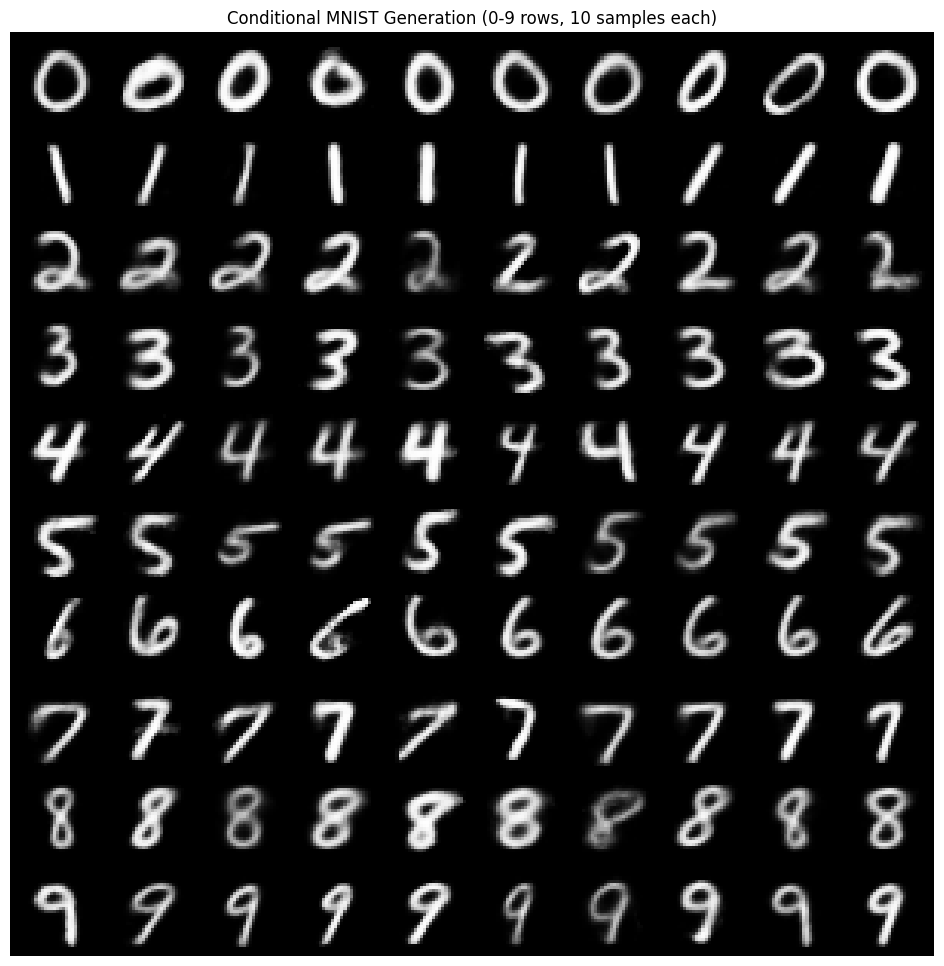

In [ ]:
# Generate 10x10 samples (10 rows, 10 samples of each digit 0-9).
# Note: sampling may be slow if n_steps is large; reduce for quick previews.
all_samples = []
for digit in range(10):  # 0 to 9
    # create a batch of 10 identical labels so we sample conditionally per class
    y = torch.full((10,), digit, device=device)  # 10 samples of same digit
    samples = conditional_langevin_latent(
        score_net, vae.decoder, y,
        n_steps=1000, eps=0.001, device=device
    )
    all_samples.append(samples)

# Concatenate all samples: [100, 1, 28, 28]
generated = torch.cat(all_samples, dim=0)

# Plot as 10x10 grid
plt.figure(figsize=(12, 12))
grid = torchvision.utils.make_grid(generated, nrow=10, padding=2)
plt.imshow(grid.cpu().permute(1, 2, 0).numpy(), cmap='gray')
plt.axis('off')
plt.title("Conditional MNIST Generation (0-9 rows, 10 samples each)")
plt.savefig("conditional_latent_ssm_grid.png", dpi=150, bbox_inches='tight')
plt.show()
